In [1]:
# note4
import math
import pygrib
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import matplotlib.path as mpath
import cartopy.crs as ccrs
import datetime
import sys
#
import metpy.calc as mpcalc
from metpy.units import units
#from scipy.ndimage.filters import maximum_filter, minimum_filter
#
import argparse

In [2]:
# GSMの読み込む初期値の年月日時をUTCで与えます。
i_year =2021
i_month = 8
i_day = 23
i_hourZ = 0
#
# 予想時間を与える。この値は注意が必要です。下3桁目が日数、下２桁で時間で与えます。
#  初期値なら0、18時間後なら18、24時間後なら100、36時間後なら112となります。
i_ft = 0
#
#  時間に変換
ft_hours=int(i_ft/100) * 24 + int(i_ft%100)
#
# Q vectorを算出る気圧面を指定
tagHp = 850
#
# 描画する範囲の大まかな指定
i_area = [115, 151, 20, 50]  #fx85 日本付近
str_area = "jp"   # ファイル名に利用
#
## GPVの切り出し領域の指定：(lonW,latS)-(lonE,latN)の矩形                                                                                                      
latS=-20
latN=80
lonW=70
lonE=190
#
# データの格納先フォルダー名
##!!! GRIB2データの保存先をFolderを指定すること !!!
data_fld="./data/gsm/"
#
## スムージングのためのパラメータ
passes=16   # 高度のスムージングの繰り返し回数
passesT=8   # = passes / 2
s_n = 9     # 9 or 5
####################################################
#
# 読み込むGRIB2形式GSMのファイル名
gsm_fn_t="Z__C_RJTD_{0:4d}{1:02d}{2:02d}{3:02d}0000_GSM_GPV_Rgl_FD{4:04d}_grib2.bin"
gr_fn= gsm_fn_t.format(i_year,i_month,i_day,i_hourZ,i_ft)
#
# データOpen
grbs = pygrib.open(data_fld + gr_fn)
#
# データ取得                                                                                                                       
grbHt = grbs(shortName="gh",typeOfLevel='isobaricInhPa',level=tagHp)[0]
grbWu = grbs(shortName="u",typeOfLevel='isobaricInhPa',level=tagHp)[0]
grbWv = grbs(shortName="v",typeOfLevel='isobaricInhPa',level=tagHp)[0]
grbTm = grbs(shortName="t",typeOfLevel='isobaricInhPa',level=tagHp)[0]
#
# データClose
grbs.close()
#
print(gr_fn)
#
## データ切り出し                                                                                                                   
valHt, latHt, lonHt = grbHt.data(lat1=latS,lat2=latN,lon1=lonW,lon2=lonE)
valWu, latWu, lonWu = grbWu.data(lat1=latS,lat2=latN,lon1=lonW,lon2=lonE)
valWv, latWv, lonWv = grbWv.data(lat1=latS,lat2=latN,lon1=lonW,lon2=lonE)
valTm, latTm, lonTm = grbTm.data(lat1=latS,lat2=latN,lon1=lonW,lon2=lonE)
#
## スムージングの実行
valHt_sm = mpcalc.smooth_n_point(valHt.squeeze(),s_n,passes) * units("gpm")
valTm_sm = mpcalc.smooth_n_point(valTm.squeeze(),s_n,passesT) * units("K")

Z__C_RJTD_20210823000000_GSM_GPV_Rgl_FD0000_grib2.bin


In [3]:
## Q vectorなどの算出のためにxarrayデータセットを作成                                                                                   
ds = xr.Dataset(
   {
       "Geopotential_height": (["lat", "lon"], valHt_sm),                                                                        
       "u_wind": (["lat", "lon"], valWu),
       "v_wind": (["lat", "lon"], valWv),
       "Temperature": (["lat", "lon"], valTm_sm),
   },
   coords={
       "level": [tagHp],
       "lat": latHt[:,0],
       "lon": lonHt[0,:],
       "time": [grbHt.validDate],
   },
)
# 単位も入力する
ds['Geopotential_height'].attrs['units'] = 'm'
ds['u_wind'].attrs['units']='m/s'
ds['v_wind'].attrs['units']='m/s'
ds['Temperature'].attrs['units']='K'
ds['level'].attrs['units'] = 'hPa'
ds['lat'].attrs['units'] = 'degrees_north'
ds['lon'].attrs['units'] = 'degrees_east'
#
# metpy仕様に変換
dsp= ds.metpy.parse_cf()
#
# 地衡風計算　平均処理した高度から求める
dsp['ug'], dsp['vg']= mpcalc.geostrophic_wind(dsp['Geopotential_height'])
#
## Q vector計算                                                                                              
dsp['u_qv'], dsp['v_qv'] = mpcalc.q_vector(dsp['ug'], dsp['vg'], dsp['Temperature'],
                                           tagHp * units.hPa)
#                                                                                                            
## 発散計算                                                                                                  
dsp['q_div'] = mpcalc.divergence(dsp['u_qv'],dsp['v_qv'])

Found valid latitude/longitude coordinates, assuming latitude_longitude for projection grid_mapping variable
Found valid latitude/longitude coordinates, assuming latitude_longitude for projection grid_mapping variable
Found valid latitude/longitude coordinates, assuming latitude_longitude for projection grid_mapping variable
Found valid latitude/longitude coordinates, assuming latitude_longitude for projection grid_mapping variable
/Users/rkurora/opt/anaconda3/envs/met_env/lib/python3.8/site-packages/pint/quantity.py:1237: RuntimeWarning: divide by zero encountered in true_divide
  magnitude = magnitude_op(new_self._magnitude, other._magnitude)
/Users/rkurora/opt/anaconda3/envs/met_env/lib/python3.8/site-packages/pint/quantity.py:1237: RuntimeWarning: invalid value encountered in multiply
  magnitude = magnitude_op(new_self._magnitude, other._magnitude)
/Users/rkurora/opt/anaconda3/envs/met_env/lib/python3.8/site-packages/pint/quantity.py:1005: RuntimeWarning: invalid value encountered

In [4]:
####  作図用処理                                                                                                           
## 年月日                                                                                                    
dt_v = grbHt.validDate
dt_i = grbHt.analDate
dt_str = (dt_i.strftime("%H00UTC%d%b%Y")).upper()
dt_str2 = dt_i.strftime("%Y%m%d%H")
#
# Q vectorの発散のハッチの指定
clevs_qdiv = list(range(-30, -4, 5))+list(range(-2,3,4))+list(range(5, 31, 5))
# 温度の等値線の指定
clevs_tmpc = np.arange(-39, 42, 3)
# 高度の等値線の指定
clevs_hght = np.arange(0, 8000, 30)
#
# 緯線・経線の指定
dlon,dlat=10,10   # 10度ごとに
#

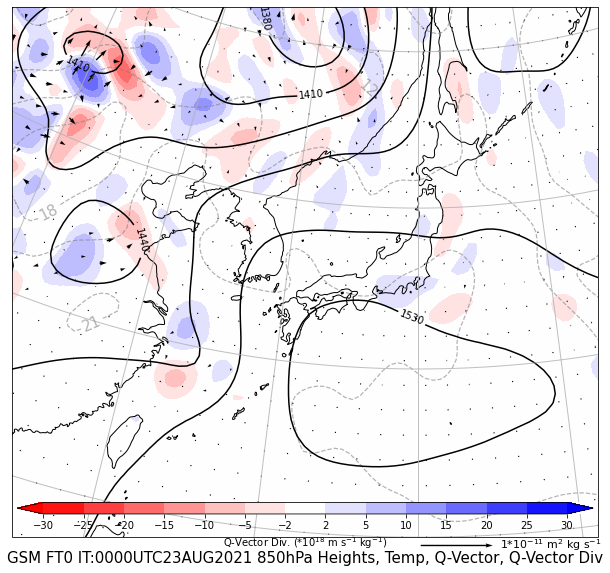

In [6]:
## 図法指定                                                                             
proj = ccrs.Stereographic(central_latitude=60, central_longitude=140)
latlon_proj = ccrs.PlateCarree()
## 図のSIZE指定inch                                                                        
fig = plt.figure(figsize=(10,8))
## 余白設定                                                                                
plt.subplots_adjust(left=0, right=1, bottom=0.06, top=0.98)                  
## 作図                                                                                    
ax = fig.add_subplot(1, 1, 1, projection=proj)
ax.set_extent(i_area, latlon_proj)
#
## 海岸線
ax.coastlines(resolution='50m',) # 海岸線の解像度を上げる                                                    
# グリッド線を引く                                                               
dlon,dlat=10,10
xticks=np.arange(0,360.1,dlon)
yticks=np.arange(-90,90.1,dlat)
gl = ax.gridlines(crs=ccrs.PlateCarree()
         , draw_labels=False
         , linewidth=1, alpha=0.8)
gl.xlocator = mticker.FixedLocator(xticks)
gl.ylocator = mticker.FixedLocator(yticks)
#
##  Plot Q-Vector Divergence and scale                                                                       
cf = ax.contourf(dsp['lon'], dsp['lat'], dsp['q_div']*1e18, clevs_qdiv,
                 cmap=plt.cm.bwr_r,
                 extend='both', transform=latlon_proj)
ax_reld = fig.add_axes([0.1, 0.1, 0.8, 0.02])
cb = plt.colorbar(cf, orientation='horizontal',
                  shrink=0.74, aspect=40, pad=0.01, cax=ax_reld,
                  ticks=clevs_qdiv)
cb.set_label('Q-Vector Div. (*10$^{18}$ m s$^{-1}$ kg$^{-1}$)')
#
## Plot Temperatures
# K=>Celsius
dsp['Temperature'] = (dsp['Temperature']).metpy.convert_units(units.degC)
cn_tmp = ax.contour(dsp['lon'], dsp['lat'], dsp['Temperature'],
                    colors='gray', alpha=0.6, linestyles='dashed',
                    linewidths=1.2, levels=clevs_tmpc, transform=latlon_proj )
ax.clabel(cn_tmp, clevs_tmpc, fontsize=15, inline=True, inline_spacing=5,
          fmt='%i', rightside_up=True)
#                                                                                                            
## Plot Geopotential Heights                                                                                 
cs = ax.contour(dsp['lon'], dsp['lat'], dsp['Geopotential_height'], clevs_hght, colors='black',
                transform=latlon_proj)
plt.clabel(cs, fmt='%d')
#                                                                                                            
## Plot Q-vectors, scale to get nice sized arrows                                                            
wind_slice = (slice(None, None, 3), slice(None, None, 3))
q = ax.quiver(dsp['lon'][wind_slice[0]], dsp['lat'][wind_slice[1]],
          dsp['u_qv'].values[wind_slice], dsp['v_qv'].values[wind_slice],
          pivot='mid', color='black',
          scale=1e-11, scale_units='inches',
          transform=latlon_proj)   # scale_units='inches'
# 凡例表示
ax.quiverkey(q, X=0.82, Y=-0.016, U=1e-11, label='1*10$^{-11}$ m$^{2}$ kg s$^{-1}$', labelpos='E',
             fontproperties={'size': 11})
#
## Caption
fig.text(0.5,0.01,"GSM FT{0:d} IT:".format(ft_hours)+dt_str+
         " {0}hPa Heights, Temp, Q-Vector, Q-Vector Div".format(tagHp) ,
         ha='center',va='bottom', size=15)
plt.show()

In [87]:
## 出力                                                                                    
output_fig_nm="gsm_{0}UTC_FT{1:03d}_qv{2}{3}.png".format(dt_str2,ft_hours,tagHp,str_area)
plt.savefig(output_fig_nm)
print("output:{}".format(output_fig_nm))

output:gsm_2021082300UTC_FT000_qv850jp.png


<Figure size 432x288 with 0 Axes>